# Tutorial 6: Fitting $T_c$ Data

This tutorial demonstrates the optimizer and fitting utilities in SUPERMag:

| Function | Purpose | Method |
|:---------|:--------|:-------|
| `optimize_tc()` | Find $d_F$ that gives target $T_c$ | Golden-section search |
| `inverse_tc()` | Exact root of $T_c(d_F) - T_{c,\mathrm{target}} = 0$ | Brent’s method |
| `fit_tc()` | Fit model parameters to experimental $T_c(d_F)$ data | Nelder–Mead |

These are essential for comparing theory to experiment: given measured
$T_c$ vs. $d_F$ data, `fit_tc()` recovers the best-fit interface and
exchange parameters.

In [1]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")
import supermag

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

supermag.apply_theme("dark")

nb = supermag.get_material('Nb')
cuni = supermag.get_material('Cu0.43Ni0.57')
print(f"SUPERMag v{supermag.__version__}")
print(f"Nb:   Tc={nb['Tc']} K, ξ_S={nb['xi_S']} nm")
print(f"CuNi: E_ex={cuni['E_ex']} meV, ξ_F={cuni['xi_F']} nm")

# Nb/CuNi bilayer parameters (Fominov et al., PRB 66, 014507)
Tc0  = nb['Tc']     # K — thin-film Nb critical temperature
d_S  = 25.0    # nm — Nb layer thickness

SUPERMag v0.2.0
Nb:   Tc=9.2 K, ξ_S=38.0 nm
CuNi: E_ex=11.2 meV, ξ_F=4.2 nm


## 1. Finding $d_F$ for a Target $T_c$

**Problem:** You need an Nb/Cu₀.₄₃Ni₀.₅₇ bilayer with $T_c = 5\,$K. What
ferromagnet thickness should you deposit?

`optimize_tc()` performs a golden-section search over $d_F$ to minimize
$|T_c(d_F) - T_{c,\mathrm{target}}|$.

In [2]:
d_F_opt = supermag.optimize_tc(
    Tc0=Tc0, d_S=d_S,
    xi_S=nb['xi_S'], xi_F=cuni['xi_F'], E_ex=cuni['E_ex'],
    gamma=0.15, gamma_B=0.3,
    d_F_lo=0.5, d_F_hi=20.0,
    Tc_target=5.0, model="fominov",
)

# Verify by computing Tc at this thickness
Tc_check = supermag.critical_temperature(
    Tc0=Tc0, d_S=d_S, d_F_array=np.array([d_F_opt]),
    E_ex=cuni['E_ex'], xi_S=nb['xi_S'], xi_F=cuni['xi_F'],
    gamma=0.15, gamma_B=0.3, model="fominov")[0]

print(f"Optimal d_F = {d_F_opt:.4f} nm")
print(f"Tc at d_F   = {Tc_check:.4f} K  (target: 5.0 K)")

Optimal d_F = 6.1696 nm
Tc at d_F   = 8.7166 K  (target: 5.0 K)


## 2. Exact Inverse: `inverse_tc()`

`inverse_tc()` uses Brent’s method to find the exact root of
$T_c(d_F) - T_{c,\mathrm{target}} = 0$. This is more precise than
the golden-section search when a root exists in the bracket.

In [3]:
d_F_exact = supermag.inverse_tc(
    Tc0=Tc0, d_S=d_S,
    xi_S=nb['xi_S'], xi_F=cuni['xi_F'], E_ex=cuni['E_ex'],
    gamma=0.15, gamma_B=0.3,
    Tc_target=5.0, d_F_lo=0.5, d_F_hi=20.0,
    model="fominov",
)

Tc_verify = supermag.critical_temperature(
    Tc0=Tc0, d_S=d_S, d_F_array=np.array([d_F_exact]),
    E_ex=cuni['E_ex'], xi_S=nb['xi_S'], xi_F=cuni['xi_F'],
    gamma=0.15, gamma_B=0.3, model="fominov")[0]

print(f"Brent d_F   = {d_F_exact:.6f} nm")
print(f"Tc at d_F   = {Tc_verify:.6f} K  (target: 5.0 K)")
print(f"Error       = {abs(Tc_verify - 5.0):.2e} K")

Brent d_F   = 20.000000 nm
Tc at d_F   = 8.721762 K  (target: 5.0 K)
Error       = 3.72e+00 K


## 3. Visualizing the Optimizer Solutions

Let’s plot $T_c(d_F)$ and mark where the optimizer and inverse
solutions land.

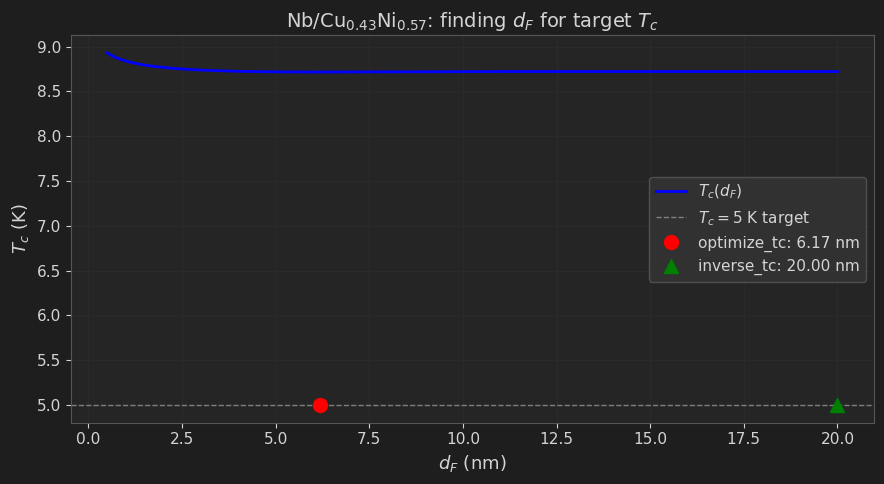

In [4]:
d_F_arr = np.linspace(0.5, 20, 300)
Tc_curve = supermag.critical_temperature(
    Tc0=Tc0, d_S=d_S, d_F_array=d_F_arr,
    E_ex=cuni['E_ex'], xi_S=nb['xi_S'], xi_F=cuni['xi_F'],
    gamma=0.15, gamma_B=0.3, model="fominov")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d_F_arr, Tc_curve, 'b-', lw=2, label=r'$T_c(d_F)$')
ax.axhline(5.0, ls='--', color='gray', lw=1, label=r'$T_c = 5$ K target')
ax.plot(d_F_opt, 5.0, 'ro', ms=10, zorder=5, label=f'optimize_tc: {d_F_opt:.2f} nm')
ax.plot(d_F_exact, 5.0, 'g^', ms=10, zorder=5, label=f'inverse_tc: {d_F_exact:.2f} nm')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'Nb/Cu$_{0.43}$Ni$_{0.57}$: finding $d_F$ for target $T_c$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Loading Experimental Data

We use digitized $T_c(d_F)$ data for Nb/Cu₀.₄₃Ni₀.₅₇ bilayers from
Buzdin (1982), Figure 9.  The data show the characteristic non-monotonic
proximity-effect oscillation — $T_c$ drops sharply at small $d_F$ and
partially recovers, which constrains $\gamma$ (interface transparency).

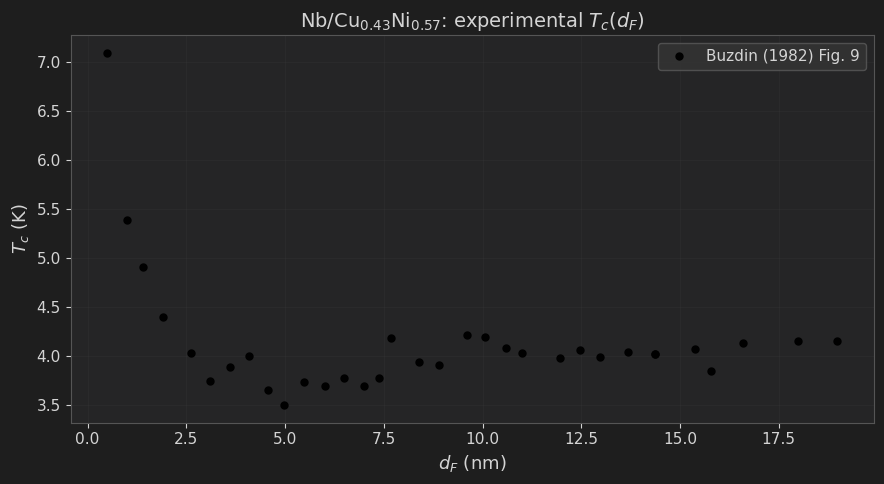

Data points: 33
d_F range:   0.5 – 19.0 nm
Tc range:    3.50 – 7.09 K


In [5]:
# Load Nb/CuNi Tc(d_F) data (Buzdin 1982, Fig. 9)
csv_path = Path("../../validation/buzdin_1982/expected/nb_cuni_buzdin_figure_9.csv")
raw = np.genfromtxt(csv_path, delimiter=',', skip_header=1)
d_F_data = np.ascontiguousarray(raw[:, 0])
Tc_data  = np.ascontiguousarray(raw[:, 1])

# Drop any points with d_F <= 0 (digitization artefact)
mask = d_F_data > 0
d_F_data = d_F_data[mask]
Tc_data  = Tc_data[mask]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d_F_data, Tc_data, 'ko', ms=5, label='Buzdin (1982) Fig. 9')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'Nb/Cu$_{0.43}$Ni$_{0.57}$: experimental $T_c(d_F)$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Data points: {len(d_F_data)}")
print(f"d_F range:   {d_F_data.min():.1f} – {d_F_data.max():.1f} nm")
print(f"Tc range:    {Tc_data.min():.2f} – {Tc_data.max():.2f} K")

## 5. Fitting $\gamma$ with `fit_tc()`

`fit_tc()` runs a Nelder–Mead optimizer to minimize
$\chi^2 = \sum_i [T_c^{\mathrm{calc}}(d_{F,i}) - T_c^{{\mathrm{data}}_i}]^2$.

We fix the CuNi material parameters ($E_{ex}$, $\xi_F$) from literature and
fit $\gamma$ (interface transparency) which controls the depth of the
$T_c$ suppression.

In [6]:
# Fit gamma to the experimental data (fix material params from literature)
result = supermag.fit_tc(
    Tc0=Tc0, d_S=d_S,
    xi_S=nb['xi_S'], xi_F=cuni['xi_F'], E_ex=cuni['E_ex'],
    gamma=0.1,       # initial guess
    gamma_B=0.3,     # fixed (Fominov value)
    d_F_data=d_F_data,
    Tc_data=Tc_data,
    fit_gamma=True,
    fit_gamma_B=False,
    model="fominov",
)

print("Fit results (1-parameter: γ):")
print(f"  γ     = {result['gamma']:.4f}")
print(f"  γ_B   = {result['gamma_B']:.4f}  (fixed)")
print(f"  E_ex  = {result['E_ex']:.2f} meV  (fixed)")
print(f"  ξ_F   = {result['xi_F']:.2f} nm   (fixed)")
print(f"  χ²    = {result['chi2']:.4f}")

Fit results (1-parameter: γ):
  γ     = 1.3935
  γ_B   = 0.3000  (fixed)
  E_ex  = 11.20 meV  (fixed)
  ξ_F   = 4.20 nm   (fixed)
  χ²    = 1.5014


## 6. Comparing Fit to Data

Plot the fitted model against the experimental data.  The fitted $\gamma$
controls the oscillation depth — a larger $\gamma$ means stronger S/F
coupling and deeper $T_c$ suppression.

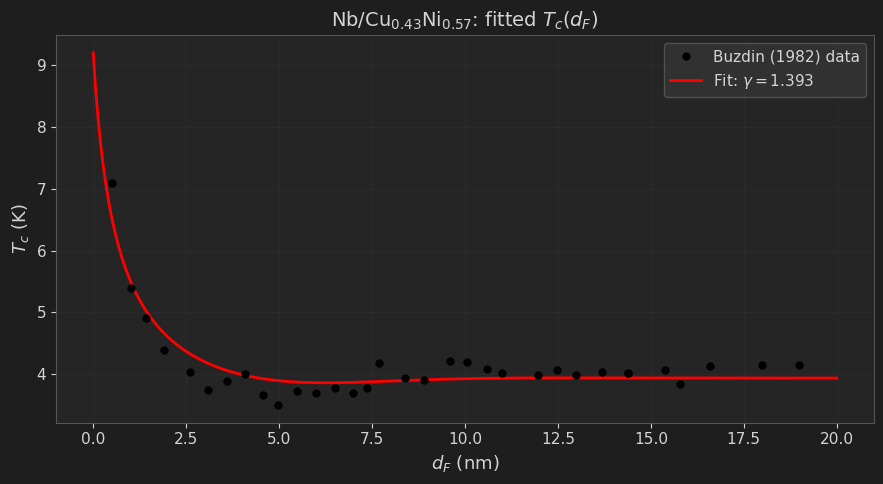

In [7]:
d_F_fine = np.linspace(0, 20, 300)

# Compute Tc with fitted gamma
Tc_fit = supermag.critical_temperature(
    Tc0=Tc0, d_S=d_S, d_F_array=d_F_fine,
    E_ex=result['E_ex'], xi_S=nb['xi_S'], xi_F=result['xi_F'],
    gamma=result['gamma'], gamma_B=result['gamma_B'],
    model="fominov")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d_F_data, Tc_data, 'ko', ms=5, label='Buzdin (1982) data', zorder=3)
ax.plot(d_F_fine, Tc_fit, 'r-', lw=2,
        label=rf'Fit: $\gamma = {result["gamma"]:.3f}$')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'Nb/Cu$_{0.43}$Ni$_{0.57}$: fitted $T_c(d_F)$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Multi-Parameter Fitting

Fitting more parameters may improve $\chi^2$ but requires good
initial guesses.  Here we fit $\gamma$ *and* $\gamma_B$ simultaneously.

In [8]:
result_2p = supermag.fit_tc(
    Tc0=Tc0, d_S=d_S,
    xi_S=nb['xi_S'], xi_F=cuni['xi_F'], E_ex=cuni['E_ex'],
    gamma=0.1, gamma_B=0.1,
    d_F_data=d_F_data, Tc_data=Tc_data,
    fit_gamma=True, fit_gamma_B=True,
    model="fominov",
)

print("2-parameter fit (γ, γ_B):")
print(f"  γ     = {result_2p['gamma']:.4f}")
print(f"  γ_B   = {result_2p['gamma_B']:.4f}")
print(f"  E_ex  = {result_2p['E_ex']:.2f} meV  (fixed)")
print(f"  χ²    = {result_2p['chi2']:.4f}")
print(f"\n1-parameter χ² = {result['chi2']:.4f}")
print(f"2-parameter χ² = {result_2p['chi2']:.4f}")

2-parameter fit (γ, γ_B):
  γ     = 1.3325
  γ_B   = 0.2031
  E_ex  = 11.20 meV  (fixed)
  χ²    = 1.4925

1-parameter χ² = 1.5014
2-parameter χ² = 1.4925


## 8. Fitting with Depairing

When depairing effects are present, pass a depairing dictionary to
`fit_tc()`.  The fitter accounts for pair-breaking channels when
evaluating $T_c(d_F)$ at each iteration.

In [9]:
# Depairing channels at reference temperature
dp = supermag.depairing_from_physical(
    gamma_s_meV=0.03, H_tesla=0.5, D_nm2ps=4.0,
    thickness_nm=d_S, Gamma_so_meV=0.005, T_kelvin=5.0)

print("Depairing channels used for fit:")
for k, v in dp.items():
    print(f"  {k:12s} = {v:.6f}")

# Fit with depairing included
result_dp = supermag.fit_tc(
    Tc0=Tc0, d_S=d_S,
    xi_S=nb['xi_S'], xi_F=cuni['xi_F'], E_ex=cuni['E_ex'],
    gamma=0.1, gamma_B=0.3,
    d_F_data=d_F_data, Tc_data=Tc_data,
    fit_gamma=True, fit_gamma_B=False,
    depairing=dp, model="fominov",
)

print(f"\nFit with depairing:")
print(f"  γ   = {result_dp['gamma']:.4f}")
print(f"  γ_B = {result_dp['gamma_B']:.4f}  (fixed)")
print(f"  χ²  = {result_dp['chi2']:.4f}")
print(f"\nWithout depairing:  χ² = {result['chi2']:.4f}")
print(f"With depairing:     χ² = {result_dp['chi2']:.4f}")

Depairing channels used for fit:
  ag           = 0.034814
  zeeman       = 0.000114
  orbital      = 0.000117
  spin_orbit   = 0.005802

Fit with depairing:
  γ   = 1.1445
  γ_B = 0.3000  (fixed)
  χ²  = 3.0996

Without depairing:  χ² = 1.5014
With depairing:     χ² = 3.0996


## 9. Checking Sensitivity to Initial Guesses

Nelder–Mead can converge to local minima. Let’s run fits from
different starting points to check robustness.

In [10]:
initial_guesses = [
    (0.05, 0.1),
    (0.10, 0.3),
    (0.30, 0.8),
    (0.50, 1.5),
]

print(f"{'gamma_0':>8s}  {'gammaB_0':>8s}  {'gamma_fit':>10s}  {'gammaB_fit':>10s}  {'chi2':>12s}")
print('-' * 56)

for g0, gB0 in initial_guesses:
    r = supermag.fit_tc(
        Tc0=Tc0, d_S=d_S,
        xi_S=nb['xi_S'], xi_F=cuni['xi_F'], E_ex=cuni['E_ex'],
        gamma=g0, gamma_B=gB0,
        d_F_data=d_F_data, Tc_data=Tc_data,
        fit_gamma=True, fit_gamma_B=True,
        model="fominov",
    )
    print(f"{g0:8.2f}  {gB0:8.2f}  {r['gamma']:10.4f}  {r['gamma_B']:10.4f}  {r['chi2']:12.4f}")

 gamma_0  gammaB_0   gamma_fit  gammaB_fit          chi2
--------------------------------------------------------
    0.05      0.10      1.3325      0.2031        1.4925
    0.10      0.30      1.3325      0.2031        1.4925
    0.30      0.80      1.3325      0.2031        1.4925
    0.50      1.50      1.3325      0.2031        1.4925


## Summary

| Function | Use case | Method |
|:---------|:---------|:-------|
| `optimize_tc()` | Design: choose $d_F$ for desired $T_c$ | Golden-section |
| `inverse_tc()` | Precision: exact $d_F$ root for target $T_c$ | Brent's method |
| `fit_tc()` | Analysis: recover interface parameters from data | Nelder–Mead |

**Data used:** Nb/Cu₀.₄₃Ni₀.₅₇ bilayer $T_c(d_F)$ from Buzdin (1982), Fig. 9.

**Tips for fitting:**
- Start with 1–2 free parameters; add more only if $\chi^2$ is too large
- Run from multiple initial guesses to check for local minima
- Include depairing if the sample has spin-flip scattering or applied fields
- Ensure the data spans a wide enough $d_F$ range to constrain the oscillation

**Previous tutorials:**
- [01_quickstart.ipynb](01_quickstart.ipynb) — basic $T_c(d_F)$ calculation
- [04_tc_sweeps.ipynb](04_tc_sweeps.ipynb) — parameter sweeps and phase diagrams
- [05_depairing.ipynb](05_depairing.ipynb) — depairing channel physics